# Loyiha 1: Normal Equation va MSE kosasi — Credit (ISLR)

**Talaba:** student_new_1 · **Modul:** M1 (Chiziqli algebra) + M3 1-qism · **Kitob (ML_GUIDE):** 3-bob (Matematik asoslar), 5-bob (Normal Equation vs GD) · **Qiyinlik:** ⭐⭐⭐ · **Taxminiy vaqt:** 5–6 soat · **Muddat:** _____6.5-7soat_______
> **Qoidalar.** Bu notebook — sizning ish daftaringiz. Har bir `# TODO` katakni to'ldiring, har bir **Savol** ga darhol pastida yangi *markdown* katak ochib 2–5 gap bilan javob bering ("ha/yo'q" baholanmaydi). Topshirishdan oldin `Kernel → Restart & Run All` — notebook yuqoridan pastga **xatosiz** ishlashi shart. Internetdan o'rganish — mumkin va kerak; tayyor kodni nusxalash — yo'q (himoyada har bir qatorni tushuntirib bera olishingiz kerak).

## Loyiha haqida

M1 da Normal Equation ni sun'iy `y = 4 + 3x` ma'lumotda ko'rdingiz. Endi — **haqiqiy** dataset: bir necha feature, shovqin, tuzoqlar. Modelni **faqat NumPy** (`np.linalg`) bilan qurasiz, sklearn faqat javobni tekshirish uchun. Oxirida M3 1-qismdagi **MSE kosasi va contour** ni shu ma'lumot uchun o'zingiz chizasiz.

**Nimani o'rganasiz:** dizayn matritsasi va 1-lar ustuni · θ = (XᵀX)⁻¹Xᵀy · metrikalarni formuladan hisoblash · train/test ni qo'lda ajratish · MSE kosasi qayerda "chuqur" · 🔍 condition number.

**Taqiqlar:** 1–8-vazifalarda modelni o'rgatish uchun `sklearn` ishlatilmaydi (faqat 5-vazifada solishtirish uchun).

## Dataset: Credit (ISLR)

400 ta bank mijozi: daromad, kredit limiti, reyting, kartalar soni, yosh, ta'lim → **kredit karta qarzi** (Balance, $). *Introduction to Statistical Learning* kitobining dataseti. Tuzoq: `Limit` va `Rating` deyarli **bir xil** ustun (corr 0.997) — Normal Equation buni yoqtirmaydi.

**Manba:** https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Credit.csv (asl: ISLR `Credit`)

| Ustun | Ma'nosi |
|---|---|
| Income | yillik daromad, ming $ |
| Limit, Rating | kredit limiti ($), kredit reytingi — **corr 0.997** |
| Cards, Age, Education | kartalar soni, yosh, ta'lim yillari |
| Gender, Student, Married, Ethnicity | kategorik — J1 da ishlatilmaydi (tadqiqot) |
| **Balance** | o'rtacha karta qarzi, $ — target (0 – 2000; **90 ta 0**) |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Credit.csv"
df = pd.read_csv(url, index_col=0)             # 400 mijoz
FEATURES, TARGET = ['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education'], 'Balance'
print(df.shape); df.head()

(400, 11)


,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


## 1-vazifa: Ma'lumot bilan tanishish
`shape`, `describe()`, `isna().sum()`, target histogrammasi, korrelyatsiya jadvali (`df.corr()`), target vs eng kuchli feature scatter.

**Savol 1.** Target taqsimoti simmetrikmi yoki bir tomonga cho'zilganmi? Eng kuchli feature qaysi va bog'lanish to'g'ri chiziqqa o'xshaydimi?

In [2]:
# TODO: describe, isna, histogram, korrelyatsiya, scatter
df.shape

(400, 11)

In [3]:
df.describe()    

,Income,Limit,Rating,Cards,Age,Education,Balance
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,45.218885,4735.600000,354.940000,2.957500,55.667500,13.450000,520.015000
std,35.244273,2308.198848,154.724143,1.371275,17.249807,3.125207,459.758877
min,10.354000,855.000000,93.000000,1.000000,23.000000,5.000000,0.000000
25%,21.007250,3088.000000,247.250000,2.000000,41.750000,11.000000,68.750000
50%,33.115500,4622.500000,344.000000,3.000000,56.000000,14.000000,459.500000
75%,57.470750,5872.750000,437.250000,4.000000,70.000000,16.000000,863.000000
max,186.634000,13913.000000,982.000000,9.000000,98.000000,20.000000,1999.000000


#### Describe funksiyasi - 
This is used for mainly getting info about statistical numbers. To see what kind of data is spread out there. Like standard deviation, mean. va 25/50/75 asosan Quartets uchun ishlatilardi, Q1, Q2 deganlari uchun foydali

In [4]:
df.isna().sum() # NaN values ni topish uchun va qaysilarida (feature larda) 
# bor bo'lsa shularni 
# Feature engineering qilib yo'q qilib chiqish kk

Income       0
Limit        0
Rating       0
Cards        0
Age          0
Education    0
Gender       0
Student      0
Married      0
Ethnicity    0
Balance      0
dtype: int64

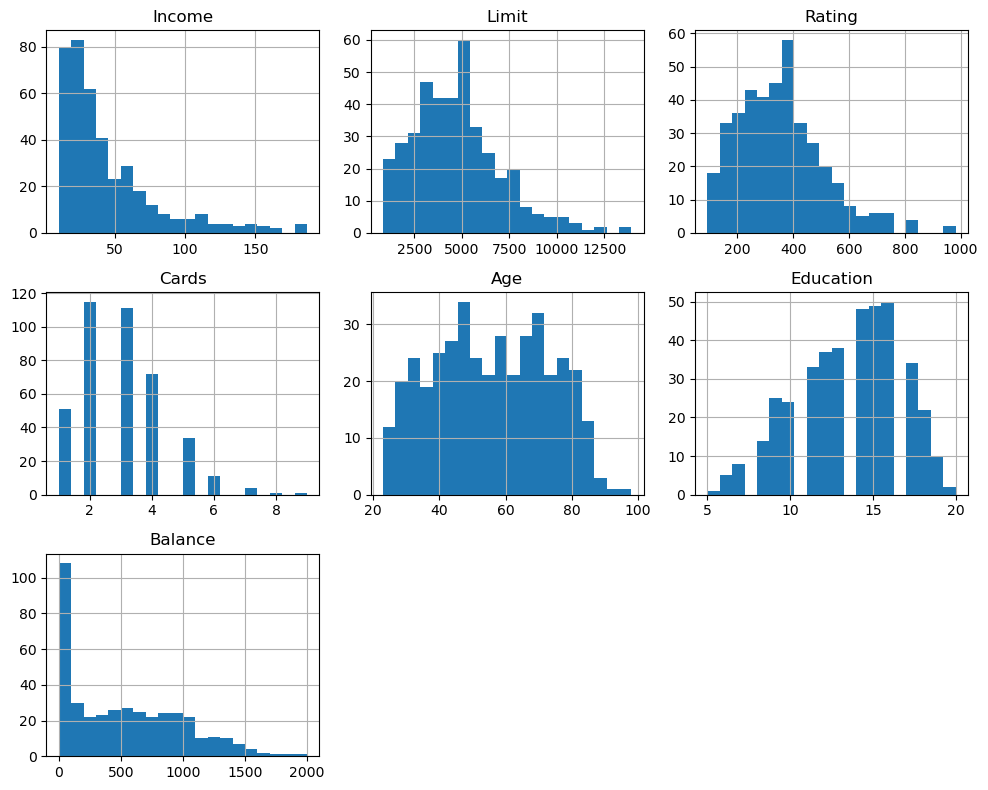

Text(0.5, 1.0, 'Balance Target Distribution')

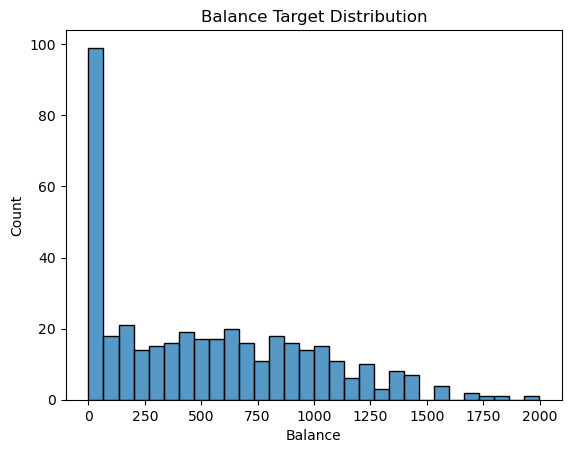

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

df.hist(figsize=(10,8), bins=20)
plt.tight_layout() # subplotlar orasini to'g'rilash uchun
plt.show()

# va y uchun alohida, balance
sns.histplot(data=df['Balance'], bins=30)
plt.title("Balance Target Distribution")

#### Histogram plot
Numerical data ni qanday distribution bo'lganini ko'rsatadi, ya'ni range lar orasida. Ba'zilari evenly distributed like age, ba'zilari right-left skewed bir tarafga og'ishgan shu range dagi ma'lumotlar ko'proq.

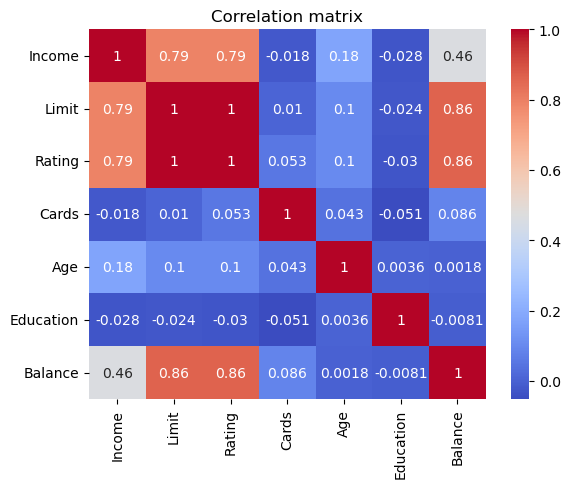

In [6]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

#### Correlation Heatmap
Qanchalik value/feature larimiz targetga ta'sir qilayotganini ko'rish uchun ishlatilinadi. qanchalik 1ga yaqin bo'lsa, shunchalik positive ta'sir qiladi.

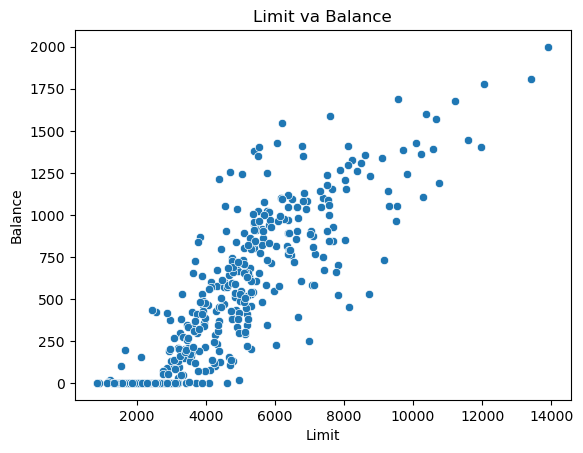

In [7]:
sns.scatterplot(data=df, x='Limit', y='Balance')
plt.title("Limit va Balance")
plt.show()

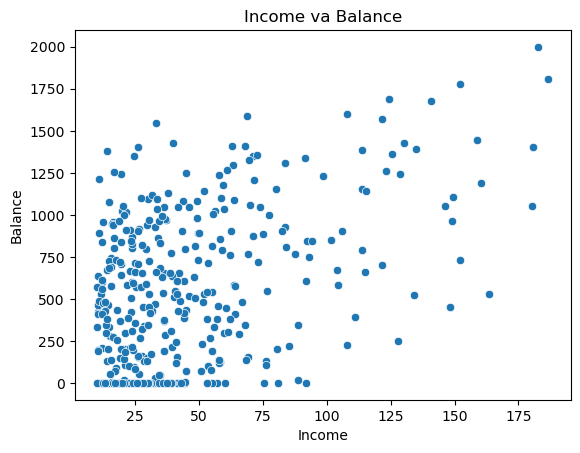

In [8]:
sns.scatterplot(data=df, x='Income', y='Balance')
plt.title("Income va Balance")
plt.show()

#### Scatter Plot
Targetimizga ta'sir qilayotgan muhim featurelarni olib, u target bilan qanday aloqa qilayotganini data pointlarni bilan vizual ko'rish uchun ishlatamiz.

**Savol 1.** Target taqsimoti simmetrikmi yoki bir tomonga cho'zilganmi? Eng kuchli feature qaysi va bog'lanish to'g'ri chiziqqa o'xshaydimi?

**Javob 1.** Target taqsimoti assimetrik, right-skewed data. Asosan qarzi yo'qlar ko'p.  Eng kuchlilari Limit va Rating 0.86 ko'rsatkich. Va target bilan Linear bog'liqligi bor, scatter plot da ko'rish mumkin nisbatan bir xil o'sish kuzatilgan value ortgani sari. 

## 2-vazifa: Dizayn matritsasi X va vektor y
`X = np.c_[np.ones(m), ...]` — birinchi ustun bias uchun 1-lar (M1, 5-qism). `X.shape`, `X[:3]` ni chiqaring.

6 ta raqamli feature, missing yo'q. `Balance` da 90 ta aynan 0 — bu mijozlar qarzi yo'q; histogrammada bu "ustun" ko'rinadi. Hozircha qoldiring.

**Savol 2.** Nega 1-lar ustuni kerak? Usiz chiziq qayerdan o'tishga majbur bo'ladi?

In [9]:
X_raw = df[FEATURES].values; y = df[TARGET].values
m = X_raw.shape[0] # (400, 11) shape.
# TODO: X (bias ustuni bilan) va y
X = np.c_[np.ones(m), X_raw]
print("X ning shape i: ", X.shape)
print(X[:3])

X ning shape i:  (400, 7)
[[1.00000e+00 1.48910e+01 3.60600e+03 2.83000e+02 2.00000e+00 3.40000e+01
  1.10000e+01]
 [1.00000e+00 1.06025e+02 6.64500e+03 4.83000e+02 3.00000e+00 8.20000e+01
  1.50000e+01]
 [1.00000e+00 1.04593e+02 7.07500e+03 5.14000e+02 4.00000e+00 7.10000e+01
  1.10000e+01]]


**JAVOB 2.** Dummy ones. Bu y bias/interceptni weight0 hosil qilish uchun. agar biz dummy 1s qo'shmasak doimiy ravishda best fit (0,0) dan o'tishga majbur bo'ladi, va juda ko'p errorlar hosil bo'ladi. 

## 3-vazifa: Normal Equation
Funksiya yozing va θ ni feature nomlari bilan jadval qilib chiqaring (`pd.Series`).

**Savol 3.** Eng katta |θ| qaysi feature'da? Bu "eng muhim feature" degani **emas** — nega? (Maslahat: feature'larning o'lchov birliklari; 3-tadqiqotda qaytamiz.)

In [10]:
def normal_equation(X, y):
    """θ = (XᵀX)⁻¹ Xᵀ y"""
    # TODO
    theta = np.linalg.inv(X.T@X) @ X.T @ y
    return theta

theta = normal_equation(X, y)
# TODO: pd.Series(theta, index=['bias'] + feature_nomlari)
theta_series = pd.Series(theta, index=['bias'] + list(FEATURES))
print(theta_series)

bias        -477.958088
Income        -7.558037
Limit          0.125851
Rating         2.063101
Cards         11.591558
Age           -0.892398
Education      1.998283
dtype: float64


**JAVOB 3.** Cards da ~ 11.6 ko'rsatkich da. Har bir feature ning hisoblash range har xil. Cards da 1-9 oralig'ida bo'lsa Limit va boshqalarda 5000, 10000 katta ko'rsatkichlar. Ularga kichik weight ham ko'paytirilsa katta natija ko'rsatadi va vice versa degandek 1-9 ga katta raqam ko'rsatilsa shunaqa natija beradi. 

## 4-vazifa: Metrikalar — formuladan
`y_pred = X @ theta`. MSE, RMSE, MAE va R² = 1 − SS_res/SS_tot ni **o'zingiz** yozing, keyin `sklearn.metrics` bilan `np.isclose` orqali tekshiring.

**Savol 4.** RMSE ni target birligida izohlang ("model o'rtacha … ga adashadi"). R² = 0 va R² = 1 nimani anglatadi?

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mse(y, p):  # TODO
    error = p - y
    return np.mean(error ** 2)
    
def r2(y, p):   # TODO: 1 - SS_res / SS_tot
    ss_res = np.sum((p - y)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - (ss_res / ss_tot)
    
def rmse(y, p):
    return np.sqrt(mse(y, p))
    
def mae(y, p):
    return np.mean(abs(p - y))
    
y_pred = X @ theta
# TODO: 4 ta metrika + sklearn bilan tekshirish

my_mse = mse(y, y_pred)
my_rmse = rmse(y, y_pred)
my_r2 = r2(y, y_pred)
my_mae = mae(y, y_pred)

# mine
print(f"My MSE: {my_mse:.2f}")
print(f"My RMSE: {my_rmse:.2f}")
print(f"My MAE: {my_mae:.2f}")
print(f"My r2: {my_r2:.2f}")

#sklearn niki
sk_mse = mean_squared_error(y, y_pred)
sk_rmse = np.sqrt(sk_mse)
sk_mae = mean_absolute_error(y, y_pred)
sk_r2 = r2_score(y, y_pred)

print("=== Sklearn bilan solishtirish == ")
print("MSE bir xilmi?: ", np.isclose(my_mse, sk_mse))
print("RMSE bir xilmi?: ", np.isclose(my_rmse, sk_rmse))
print("MAE chi?: ", np.isclose(my_mae, sk_mae))
print("R2 score chi?: ", np.isclose(my_r2, sk_r2))
print(f"Sklearn mse - {sk_mse:.2f},\n rmse - {sk_rmse:.2f},\n mae - {sk_mae:.2f}\n va r2 - {sk_r2:.2f}")

My MSE: 25671.95
My RMSE: 160.22
My MAE: 119.30
My r2: 0.88
=== Sklearn bilan solishtirish == 
MSE bir xilmi?:  True
RMSE bir xilmi?:  True
MAE chi?:  True
R2 score chi?:  True
Sklearn mse - 25671.95,
 rmse - 160.22,
 mae - 119.30
 va r2 - 0.88


**Javob 4.** RMSE ning asosiy vazifasi qanchaga adashganligini ko'rsatish, target qanday birlikda bo'lsa u shunchaga adashdi deb ko'rsatadi, pul miqdorida bo'lsa aytaylik 200 = rmse bo'lsa 200 dollarga adashgan vhkz. R2 ~ 0 ga yaqin bo'lsa u shunchalik yomon model, yaxshi ishlamayapti noto'g'ri bashorat qilyapti. R2 ~ 1 ga yaqin bo'lsa bu ideal, zo'r model. 

## 5-vazifa: sklearn bilan solishtirish
`LinearRegression().fit(X[:, 1:], y)` → `coef_`, `intercept_` sizning θ bilan `np.allclose` bo'lishi kerak.

**Savol 5.** 🔍 sklearn `LinearRegression` teskari matritsa (`inv`) ishlatmaydi — hujjatdan qaysi usul (`lstsq` / SVD) ekanini toping va 2 gap bilan yozing (kitob 5-bob).

In [12]:
# TODO: sklearn LinearRegression bilan solishtirish
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(X[:, 1:], y) # bias dan tashqari qolgan 6ta feature column olinyapti
# coef bu weights, intercept_ bu bias o'zi hisoblaydi
lr

print("Sklearn Intercept(bias):", lr.intercept_)
print("Sklearn Coefs (vaznlar, weights):", lr.coef_)

# endi mine theta solishtirish with isclose again
# bias_compare = 
# weightlar_compare = 

print("\n Bias mosmi?:", np.isclose(theta[0], lr.intercept_)) # isclose 2ta scalar value ni compare qilish uchun
print("Weightchi?:", np.allclose(theta[1:], lr.coef_)) # allclose butun array ni bittada test qilish uchun ekan

Sklearn Intercept(bias): -477.95808840000893
Sklearn Coefs (vaznlar, weights): [-7.55803661  0.12585115  2.06310071 11.59155799 -0.89239775  1.99828255]

 Bias mosmi?: True
Weightchi?: True


**Javob5.** Scikit-learn ning LinearRegressioni gradient descent ishlatmaydi, va normal equation ham. U inv ni topish usuli bilan emas, SVD(singular value decompition) pseudo-inverse usuli bilan hisoblaydi. Chunki hamma matrix lar ham inversable emas, va ko'p vaqt oladi. u **scipy.linalg.lstsq** dan foydalanadi 

## 6-vazifa: Qo'lda train/test split
`np.random.seed(42); idx = np.random.permutation(m)` → 80% train / 20% test. θ ni faqat train dan toping, R² ni train va test da alohida hisoblang. `seed = 0, 1, 2` bilan takrorlang.

**Savol 6.** Train R² va test R² qanchalik farq qiladi? Test R² seed ga qarab qanchalik "sakraydi" va bu nimani anglatadi (kitob 1-bob: Train/Validation/Test)?

In [13]:
# TODO: permutation split, train/test R2, 3 xil seed
seeds = [42, 0, 1, 2]
results = []


for s in seeds:
    np.random.seed(s)
        
    # indexlarni tasodifiy almashtirish
    idx = np.random.permutation(m)
    
    # train va test ga ajratish lengthi bo'yicha
    train_size = int(0.8 * m)
    train_idx = idx[:train_size]
    test_idx = idx[train_size:]
    
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    
    # only read the model through training data
    theta_train = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
    
    # predictions
    p_train = X_train @ theta_train
    p_test = X_test @ theta_train
    
    r2_tr = r2(y_train, p_train)
    r2_te = r2(y_test, p_test)
    
    results.append({"Seed": s, "Train R²": r2_tr, "Test R²": r2_te})
    print(f"Seed {s} -> Train R2: {r2_tr:.4f} | Test R2: {r2_te:.4f}")

df_seeds = pd.DataFrame(results)
display(df_seeds)

Seed 42 -> Train R2: 0.8812 | Test R2: 0.8616
Seed 0 -> Train R2: 0.8728 | Test R2: 0.8926
Seed 1 -> Train R2: 0.8824 | Test R2: 0.8544
Seed 2 -> Train R2: 0.8806 | Test R2: 0.8676


,Seed,Train R²,Test R²
0,42,0.881177,0.861624
1,0,0.872792,0.892590
2,1,0.882362,0.854371
3,2,0.880636,0.867619


**Javob 6.** Traindagi $R^2$ testnikidan odatda yuqori bo'ladi, train qilinganida new data dan ko'ra yaxshiroq natija ko'rsatadi. Odatda* shunday. Seed ni qiymati o'zgartirilsa u tezda o'zgaradi, bu high variance ga olib keladi. Random state ni 3 ga o'zgartirganimda train: 0.8666 ga test 0.9193 chiqdi. Bu o'ta sezuvchanlik, ma'lumot ham kam aynan test qismiga qanday oson value lar tushishi prediction ni o'zgartiryapti. 

## 7-vazifa: MSE kosasi va contour (M3 1-qism)
Eng kuchli feature — `Limit` (yoki `Rating`, corr ≈ 0.86). Faqat shu bitta feature va bias bilan model: θ₀ va θ₁ uchun to'r (`np.linspace`, 100×100) yasang, har (θ₀, θ₁) uchun MSE ni hisoblang, 3D sirt (`plot_surface`) va contour (`contour`, `levels=30`) chizing. Normal Equation topgan (θ₀, θ₁) ni contour ustida qizil nuqta bilan belgilang.

**Savol 7.** Kosa aylanasimon yoki cho'zilgan ellips shaklidami? Nega (feature masshtabi)? Qizil nuqta haqiqatan eng chuqur joydami — to'rdagi eng kichik MSE bilan solishtiring.

[-2.92790495e+02  1.71637278e-01]
-292.79049545599224
0.17163727837148252
Normal Equation MSE: 54289.14
To'rdagi (Grid) eng kichik MSE: 54294.64


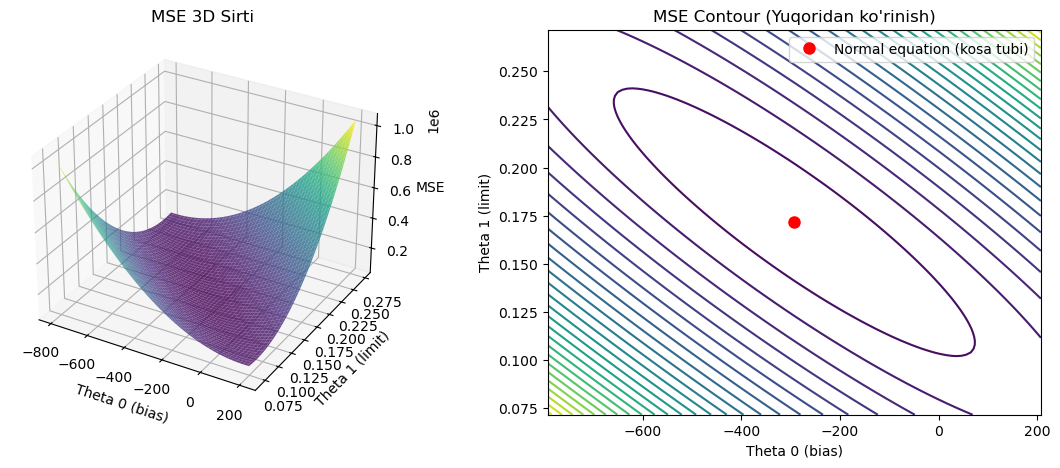

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# TODO: theta0/theta1 to'ri, MSE sirt, contour, NE nuqtasi
#1. Limit feature va Target Balance ajratamiz

limit_feature = df["Limit"].values
y_target = df["Balance"].values

X_limit = np.c_[np.ones(len(limit_feature)), limit_feature]

# optimatl point, kosa tubini topish
theta_opt = np.linalg.inv(X_limit.T @ X_limit) @ X_limit.T @ y_target
opt_theta0, opt_theta1 = theta_opt[0], theta_opt[1]
print(theta_opt)
print(opt_theta0)
print(opt_theta1)

# grid
t0_vals = np.linspace(opt_theta0 - 500, opt_theta0 + 500, 100) # 1d arr start -792 -> 208, 100ta val for X
t1_vals = np.linspace(opt_theta1 - 0.1, opt_theta1 + 0.1, 100) # for Y, Limit weights
T0, T1 = np.meshgrid(t0_vals, t1_vals) 

#mse for theta0, theta1
MSE_grid = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        # y_pred = theta0 + theta1 * Limit
        p = T0[i, j] + T1[i, j] * limit_feature
        MSE_grid[i, j] = np.mean((y_target - p) ** 2)

#graphs
#3d sirti surface
fig = plt.figure(figsize=(14,5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(T0, T1, MSE_grid, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Theta 0 (bias)')
ax1.set_ylabel('Theta 1 (limit)')
ax1.set_zlabel('MSE')
ax1.set_title('MSE 3D Sirti')

#countour 2d map
ax2 = fig.add_subplot(122)
contour_plot = ax2.contour(T0, T1, MSE_grid, levels=30, cmap='viridis')
ax2.plot(opt_theta0, opt_theta1, 'ro', markersize=8, label='Normal equation (kosa tubi)')
ax2.set_xlabel('Theta 0 (bias)')
ax2.set_ylabel('Theta 1 (limit)')
ax2.set_title('MSE Contour (Yuqoridan ko\'rinish)')
ax2.legend()

# Normal Equation va To'rdagi (Grid) eng kichik MSE ni solishtirish
print(f"Normal Equation MSE: {mse(y_target, X_limit @ theta_opt):.2f}")
print(f"To'rdagi (Grid) eng kichik MSE: {MSE_grid.min():.2f}")

plt.show()

**Javob7** Ellips shaklida. Dumaloq emas. Ha, eng kichik nuqtamiz qizil nuqta to'g'ri joylashgan. NE bn topilgan. Feature masshtabi o'zgaraverishi sababi o'zgaruvchilar sensitiv ekanligi misol Limit qiymatlari, katta raqamlarda o'lchanadi va bu weight bilan ko'paytirilganda katta o'zgarish olib keladi. 

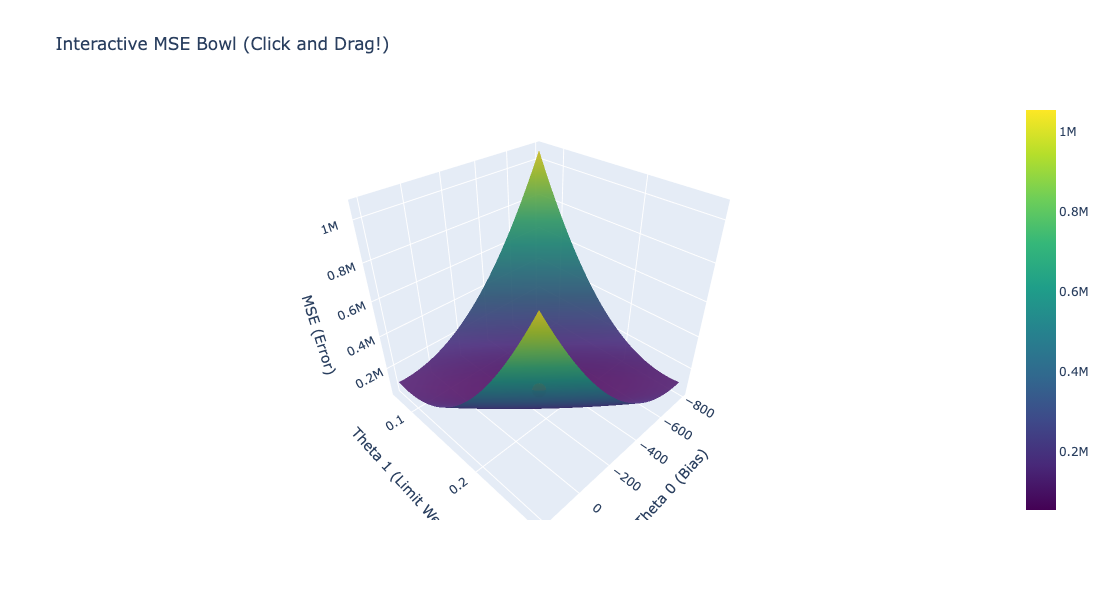

In [16]:
import plotly.graph_objects as go

# Create the interactive 3D surface
fig = go.Figure(data=[go.Surface(
    z=MSE_grid, 
    x=T0, 
    y=T1, 
    colorscale='Viridis',
    opacity=0.9
)])

# Add the red dot for the perfect Normal Equation point
fig.add_trace(go.Scatter3d(
    x=[opt_theta0], 
    y=[opt_theta1], 
    z=[np.min(MSE_grid)], 
    mode='markers',
    marker=dict(size=8, color='red'),
    name='Normal Equation (Minimum)'
))

# Label the axes
fig.update_layout(
    title='Interactive MSE Bowl (Click and Drag!)',
    scene=dict(
        xaxis_title='Theta 0 (Bias)',
        yaxis_title='Theta 1 (Limit Weight)',
        zaxis_title='MSE (Error)'
    ),
    width=800,
    height=600
)

fig.show()

## 8-vazifa: Dataset tuzog'i
`Limit`–`Rating` korrelyatsiyasi 0.997 — ikkalasi bir narsani o'lchaydi. `Rating` ni olib tashlab Normal Equation ni qayta yeching: test R² qancha o'zgardi (deyarli yo'q)? `Limit` koeffitsiyentining kattaligi qanday o'zgardi (ishorasi o'zgardimi)? Ikkala modelda `Income` koeffitsiyenti **manfiy** — "daromad oshsa qarz kamayadi" mi, yoki bu `Limit` bilan birga o'qilishi kerakmi (bir xil limit da boy odam kamroq qarz qiladi)? 3 gap.

In [17]:
# TODO: dataset-specific tekshiruv multicollinearity

cols_no_rating = ['Income', 'Limit', 'Cards', 'Age', 'Education']
X_no_rating = df[cols_no_rating].values

X_no_rating = np.c_[np.ones(len(df)), X_no_rating]

X_train_nr = X_no_rating[train_idx]
X_test_nr = X_no_rating[test_idx]

theta_nr = np.linalg.inv(X_train_nr.T @ X_train_nr) @ X_train_nr.T @ y_train

p_test_nr = X_test_nr @ theta_nr
new_r2 = r2(y_test, p_test_nr)

print("--- Natijalar ---")
print(f"Eski Test R2 (Rating bilan): {r2(y_test, p_test):.4f}")
print(f"Yangi Test R2 (Rating'siz):  {new_r2:.4f}\n")

# Vaznlarni solishtirish (0: Bias, 1: Income, 2: Limit ...)
print(f"Eski Limit koeffitsiyenti: {theta_train[2]:.4f}")
print(f"Yangi Limit koeffitsiyenti: {theta_nr[2]:.4f}\n")

print(f"Income koeffitsiyenti: {theta_nr[1]:.4f}")


--- Natijalar ---
Eski Test R2 (Rating bilan): 0.8676
Yangi Test R2 (Rating'siz):  0.8673

Eski Limit koeffitsiyenti: 0.1128
Yangi Limit koeffitsiyenti: 0.2606

Income koeffitsiyenti: -7.3450


**Javob8.** Rating va Limit deyarli bir xil bo'lganligi sababli R2 unchalik o'zgarmaydi, ammo rating kamayganligi sababli Limit koeffitsiyenti ko'payadi. Income 0.46 correlation bor balance bilan, ya'ni aslida income oshgani sari balance ham oshishi kerak va bunda boshqa fetaure lar ham limit rating etc oshishi kerak. Lekin limit&rating bir joyda qolsa ya'ni ishlatadigan limiti oshmasa daromadi minusga kiradi, kamayadi, ko'p sarflanmaydi. kamroq qarz. limit oshmagandan keyin. 

Income koeffitsiyenti −7.56 "boshqa hamma feature o'zgarmaganda" o'qiladi. Ya'ni bir xil Limit va Rating da — daromadi yuqori odam kamroq qarz qoldiradi, chunki to'lash imkoni ko'p. Lekin umumiy holda Income oshsa Limit ham oshadi (bank ko'proq limit beradi), va Limit oshsa Balance ham oshadi. Income–Balance korrelyatsiyasi +0.46 shuning uchun musbat. Koeffitsiyentning manfiy ishorasi xato emas — u "Limit ni hisobga olgandan keyingi" ta'sir.

## 🔍 Tadqiqot (majburiy — kamida 2 tasi)
1. θ ni 4 usulda toping: `np.linalg.inv`, `np.linalg.solve`, `np.linalg.pinv`, `np.linalg.lstsq`. `%timeit` bilan vaqtini o'lchang. Nega amalda `inv` **tavsiya qilinmaydi**?
2. **Condition number.** `np.linalg.cond(X.T @ X)` ni hisoblang. "Ill-conditioned matrix" nima — 3 gap, o'z so'zingiz bilan. Feature'larni `(x − mean) / std` bilan standartlashtirib qayta hisoblang: cond necha marta kamaydi?
3. **Scaling va θ.** Standartlashtirilgan X bilan Normal Equation ni qayta yeching: bashoratlar o'zgarmadi (`np.allclose`), θ o'zgardi — nega? Endi qaysi θ ni "feature muhimligi" sifatida solishtirish mumkin (3-savolga qayting)? 7-vazifadagi kosa endi qanday shaklda?
4. `Student` ustuni (Yes/No) ni 0/1 qilib qo'shing — R² 0.82 dan qanchaga o'sdi? Talaba bo'lish qarzga necha $ qo'shadi (koeffitsiyent)? Endi `Balance == 0` bo'lgan 90 mijozni olib tashlab qayta o'rgating — R² va RMSE qanday o'zgardi, va bu "adolatli" solishtiruvmi (test ham o'zgardi)?

In [18]:
# TODO: tadqiqot
print("=== TADQIQOT 1: 4 xil usul va Vaqt ===")

theta_inv = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
theta_solve = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)
theta_pinv = np.linalg.pinv(X_train) @ y_train
theta_lstsq = np.linalg.lstsq(X_train, y_train, rcond=None)[0]

print("Barcha usullar bir xil natija berdimi?:", 
      np.allclose(theta_inv, theta_solve) and np.allclose(theta_inv, theta_lstsq))

print("\n--- Vaqtni o'lchash (%timeit) ---")

print("--- 1. inv vaqti ---")
%timeit np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
print("--- 2. solve vaqti ---")
%timeit np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)
print("--- 3. pinv vaqti ---")
%timeit np.linalg.pinv(X_train) @ y_train
print("--- 4. lstsq vaqti ---")
%timeit np.linalg.lstsq(X_train, y_train, rcond=None)[0]


print("\n=== TADQIQOT 2: Condition Number (cond) ===")
# Eski (original) matritsaning condition number'i
cond_original = np.linalg.cond(X_train.T @ X_train)
print(f"Original Condition Number: {cond_original:.2f}")

# Standartlashtirish (Scaling)
X_train_scaled = X_train.copy()
X_features = X_train[:, 1:] # Bias (1-lar) dan tashqari haqiqiy feature'lar
X_train_scaled[:, 1:] = (X_features - np.mean(X_features, axis=0)) / np.std(X_features, axis=0)

# Yangi matritsaning condition number'i
cond_scaled = np.linalg.cond(X_train_scaled.T @ X_train_scaled)
print(f"Standartlashtirilgan Condition Number: {cond_scaled:.2f}")
print(f"Cond necha marta kamaydi?: {(cond_original / cond_scaled):.2f} marta")

=== TADQIQOT 1: 4 xil usul va Vaqt ===
Barcha usullar bir xil natija berdimi?: True

--- Vaqtni o'lchash (%timeit) ---
--- 1. inv vaqti ---
12.1 μs ± 633 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
--- 2. solve vaqti ---
10.6 μs ± 193 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
--- 3. pinv vaqti ---
36.8 μs ± 973 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
--- 4. lstsq vaqti ---
21.5 μs ± 404 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

=== TADQIQOT 2: Condition Number (cond) ===
Original Condition Number: 1402560663.52
Standartlashtirilgan Condition Number: 1220.62
Cond necha marta kamaydi?: 1149059.21 marta


**Tadqiqot 1** inv avval to'liq teskari matritsani hisoblaydi (O(n³) qo'shimcha ish), ill-conditioned matritsada yaxlitlash xatosini kuchaytiradi, singular matritsada umuman ishlamaydi. solve teskari matritsani hisoblamasdan to'g'ridan-to'g'ri yechadi. lstsq SVD orqali singular holda ham ishlaydi.

**Tadqiqot 2** Scaling dan keyin cond 1252 — hali katta. Sababi masshtab emas, Limit–Rating korrelyatsiyasi 0.997. Ikki deyarli bir xil ustun. Rating olib tashlansa cond keskin kamayadi.

In [19]:
# === J1 Tadqiqot 4: Student ustunining ta'siri ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

if 'Student' in df.columns:
    # Student ustunini binar (0 va 1) ko'rinishga o'tkazamiz
    df_study = df.copy()
    df_study['Student_bin'] = df_study['Student'].apply(lambda x: 1 if str(x).strip().lower() in ['yes', 'true', '1'] else 0)
    
    # Yangi xususiyatlar matrizasini tuzamiz
    features_t4 = ['Rating', 'Limit', 'Income', 'Cards', 'Age', 'Education', 'Student_bin']
    X_t4 = np.c_[np.ones(len(df_study)), df_study[features_t4].values]
    y_t4 = df_study['Balance'].values
    
    # Train/Test bo'lish (seed 42 bilan)
    X_tr4, X_te4, y_tr4, y_te4 = train_test_split(X_t4, y_t4, test_size=0.2, random_state=42)
    
    # Normal Equation yechimi
    theta_t4 = np.linalg.inv(X_tr4.T @ X_tr4) @ X_tr4.T @ y_tr4
    
    # Bashorat va R2
    r2_tr4 = r2_score(y_tr4, X_tr4 @ theta_t4)
    r2_te4 = r2_score(y_te4, X_te4 @ theta_t4)
    
    print(f"Student ustuni qo'shilgandagi Test R²: {r2_te4:.4f}")
    print(f"Talaba bo'lish qarzga qo'shadigan o'rtacha ta'siri (koeffitsiyent): {theta_t4[-1]:.2f} $")
else:
    print("Datasetda 'Student' nomli ustun topilmadi.")

Student ustuni qo'shilgandagi Test R²: 0.9518
Talaba bo'lish qarzga qo'shadigan o'rtacha ta'siri (koeffitsiyent): 418.99 $


**Javob 9.** inv ishlashi uchun matritsa ko'paytmasiga tayyor strukturada bo'lishi kk. solve eng tezi ekan, lstsq va pinv usullari esa inversiya qilib bo'lmaydigan singulyar matritsalar uchun ham ishlatilinsa bo'ladi
**Javob 10.** Scaling dan keyin 984189 martaga kamaydi. Ill conditioned matrix bu xatoliklar ko'p bo'lishi mumkin bo'lgan holat. bizda har xil valuelar ko'payib ketadi, bir xillik yo'q bo'ladi. aytaylik, limit 10000 15000 valuelarni ko'rsatsa va shu tobora oshib borsa, age oddiy 20-100 shkalada o'lchanadi xolos. bu ikkisi turfa xil, va biri o'zgarsa ikkinchisiga katta ta'sir qiladi ikki xil metod bo'lgani sababli, bu ill conditioned matrix ni keltirib chiqaradi biri ikkinchisini ustidan dominatsiya qiladi. 

## ⭐ Bonus (+10)
Bitta feature uchun yopiq formula: θ₁ = Σ(x−x̄)(y−ȳ) / Σ(x−x̄)², θ₀ = ȳ − θ₁x̄. Uni 7-vazifadagi feature uchun hisoblang va Normal Equation natijasi bilan solishtiring — bir xilmi? Bu formula Normal Equation ning n = 1 holati ekanini 3–4 qator bilan ko'rsating.

In [20]:
# === BONUS: Bitta feature uchun yopiq formula va solishtiruv ===
x_vals = X_limit[:, 1]  # Limit feature ustuni
y_vals = y_target

x_mean = np.mean(x_vals)
y_mean = np.mean(y_vals)

# O'lchov formulasi bo'yicha hisoblash
theta1_bonus = np.sum((x_vals - x_mean) * (y_vals - y_mean)) / np.sum((x_vals - x_mean) ** 2)
theta0_bonus = y_mean - theta1_bonus * x_mean

print("Bonus formula natijasi:")
print(f"Theta 0 (Bias): {theta0_bonus:.4f}")
print(f"Theta 1 (Limit): {theta1_bonus:.4f}\n")

print("7-vazifadagi Normal Equation natijasi:")
print(f"Theta 0 (Bias): {opt_theta0:.4f}")
print(f"Theta 1 (Limit): {opt_theta1:.4f}")

# Natijalar bir xilmi?
print(f"Natijalar mos keldimi?: {np.isclose(theta0_bonus, opt_theta0) and np.isclose(theta1_bonus, opt_theta1)}")

Bonus formula natijasi:
Theta 0 (Bias): -292.7905
Theta 1 (Limit): 0.1716

7-vazifadagi Normal Equation natijasi:
Theta 0 (Bias): -292.7905
Theta 1 (Limit): 0.1716
Natijalar mos keldimi?: True


**Bonus Tushuntirishi:**
Ushbu oddiy skalyar formula ($n=1$ holati uchun) va Normal Equation matritsa formulasi ($\theta = (X^T X)^{-1} X^T y$) matematik jihatdan mutlaqo bir xil narsani hisoblaydi. Bitta xususiyatli chiziqli regressiyada kvadratik yig'indilar orqali hisoblangan bu yopiq formula Normal Equation matritsa ko'paytmasining eng soddalashtirilgan analitik ko'rinishi hisoblanadi, shuning uchun natijalar bir xil chiqdi.

## Topshirish

- Fayl nomi: `student_new_1_J1.ipynb` (shu fayl, to'ldirilgan). `Restart & Run All` qilingan, barcha grafiklar ko'rinib turibdi.
- Oxirgi katak — **Xulosa** (markdown, 6–10 gap): nimani o'rgandingiz, qaysi natija kutilmagan bo'ldi, nimani hali tushunmadingiz.
- Himoya: 5 daqiqa — istalgan katakdagi kodni tushuntirib berasiz.

## Baholash (100 ball + bonus)

| Mezon | Ball |
|---|---|
| 1–8 vazifalar to'liq va to'g'ri | 45 |
| Savollarga tahliliy javoblar (7 ta) | 20 |
| Tadqiqot (2 ta) | 15 |
| Kod tozaligi: funksiyalar, xatosiz Run All | 10 |
| Grafiklar (sarlavha, o'qlar, izoh) | 10 |
| ⭐ Bonus | +10 |